In [2]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

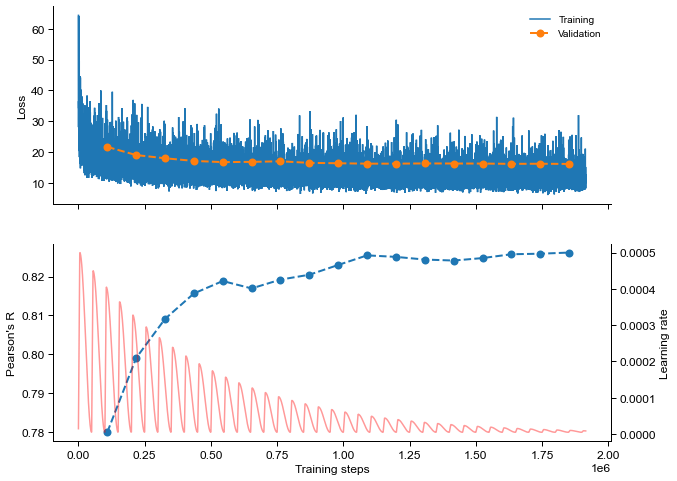

In [9]:
metrics = pd.read_csv(
   # "/home/jvierstra/proj/vinson/models/data_OCT8_with_warmup_and_decay_v2/logs/lightning_logs/version_0/metrics.csv"
   "/home/jvierstra/proj/vinson/models/data_AUG3_with_warmup_and_decay_v2/logs/lightning_logs/version_0/metrics.csv"
)

i = metrics.loss.abs() > 100
metrics.loc[i, "loss"] = pd.NA


val_steps = ~metrics.val_loss.isna()
val_metrics = metrics[val_steps]
train_metrics = metrics[~val_steps]

fig, ax = plt.subplots(2, 1, sharex=True)

# ax[0].set_xlim(0, 5000)
i = ~np.isnan(metrics.loss)
ax[0].plot(metrics.step[i], metrics.loss[i], label="Training")
ax[0].plot(
    val_metrics.step, val_metrics.val_loss, "o--", lw=2, ms=8, label="Validation"
)

ax[0].set_ylabel("Loss")
ax[0].legend()

# ax[0].set_xlim(left=1e6)
#ax[0].set_ylim(6, 25)


ax[1].plot(val_metrics.step, val_metrics.val_pcc, "o--", lw=2, ms=8, label="Correlation")
ax[1].set_xlabel("Training steps")
ax[1].set_ylabel("Pearson's R")

i = ~np.isnan(metrics["lr"])

tax = ax[1].twinx()
tax.plot(metrics.step[i], metrics["lr"][i], color="red", alpha=0.4, label="Learning rate")
tax.set_ylabel("Learning rate")

ax[1].spines["right"].set_visible(True)

fig.set_size_inches(10, 8)

(5000.0, 20050.8)

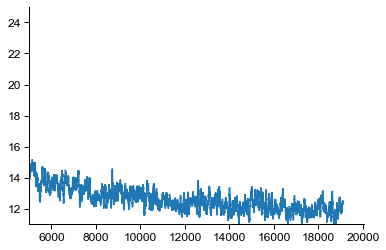

In [10]:
def moving_average(a, n=3):
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:] / n

plt.plot(moving_average(metrics.loss[~metrics.loss.isna()].values, n=50))
plt.ylim(11, 25)
plt.xlim(left=5_000)


In [8]:
val_metrics

,epoch,loss,lr,step,val_loss,val_pcc
5606,0.0,NaN,NaN,280351,27.869776,0.784913
11215,0.0,NaN,NaN,560703,27.672531,0.787302
16822,0.0,NaN,NaN,841055,26.817762,0.798234
22431,0.0,NaN,NaN,1121407,26.592505,0.798223
28038,0.0,NaN,NaN,1401759,25.821033,0.803379
33647,1.0,NaN,NaN,1682110,26.050238,0.805291
39254,1.0,NaN,NaN,1962461,26.003393,0.804654
44863,1.0,NaN,NaN,2242812,26.307537,0.806458
50470,1.0,NaN,NaN,2523163,25.995718,0.804565
56079,1.0,NaN,NaN,2803514,25.948465,0.806418
